# Predictive Modelling: Thin File vs Traditional XGBoost Models

Two separate XGBoost classifiers are trained — one for **Thin File** borrowers (alternative-data features only) and one for **Traditional** borrowers (alternative + credit-bureau features). Keeping them separate prevents the traditional model's reliance on credit score from penalizing thin-file applicants who simply lack that data.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/borrower_features.csv')
df.head()

,borrower_id,age,location,employment_type,borrower_type,credit_score,traditional_payment_history_pct,credit_inquiries,utility_on_time_pct,rent_avg_days_late,...,job_tenure_months,monthly_income,income_fluctuation_pct,existing_debt,is_default,savings_ratio,debt_to_income_ratio,income_stability_score,is_gig_worker,payment_reliability_score
0,B_000000,56,Suburban,Unemployed,Thin File,NaN,NaN,NaN,0.589528,0.090301,...,0.005814,4256.85,45.83,1102.83,1,0.000266,0.002231,0.083217,0,0.767674
1,B_000001,69,Urban,Salaried,Traditional,660.345321,70.440420,1.0,0.615900,0.086612,...,0.113372,2569.61,6.21,40.87,0,0.001289,0.000124,0.875775,0,0.781966
2,B_000002,46,Urban,Self-Employed,Traditional,781.066181,71.018850,3.0,0.498373,0.121845,...,0.017442,3919.33,9.49,650.99,0,0.000138,0.001425,0.810162,0,0.712633
3,B_000003,32,Rural,Salaried,Traditional,620.043362,84.113594,0.0,0.723167,0.422473,...,0.026163,6463.19,9.97,1458.34,1,0.000367,0.001941,0.800560,0,0.734842
4,B_000004,60,Urban,Self-Employed,Traditional,726.648661,73.627261,0.0,0.845216,0.062977,...,0.264535,17874.37,32.56,1180.48,0,0.000379,0.000558,0.348670,0,0.870382


In [2]:
def train_evaluate_model(X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f"--- {model_name} Model ---")
    print(f"ROC AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

    # Plots: ROC curve, confusion matrix, feature importance
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
    axes[0].set_title(f'{model_name}: ROC Curve')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title(f'{model_name}: Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(8)
    sns.barplot(data=importance, x='Importance', y='Feature', ax=axes[2], palette='viridis')
    axes[2].set_title(f'{model_name}: Top Features')

    plt.tight_layout()
    plt.show()

    return model

## Thin File Model

/Users/vishalpatil/Data Science/Thin File Borrower Risk Assessment Platform/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:31:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Thin File Model ---
ROC AUC: 0.5696
              precision    recall  f1-score   support

           0       0.68      0.91      0.78       417
           1       0.46      0.15      0.22       212

    accuracy                           0.66       629
   macro avg       0.57      0.53      0.50       629
weighted avg       0.61      0.66      0.59       629



/var/folders/1w/wn31x_g14vbd2br3ln9s2nrc0000gn/T/ipykernel_37649/967286594.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', ax=axes[2], palette='viridis')


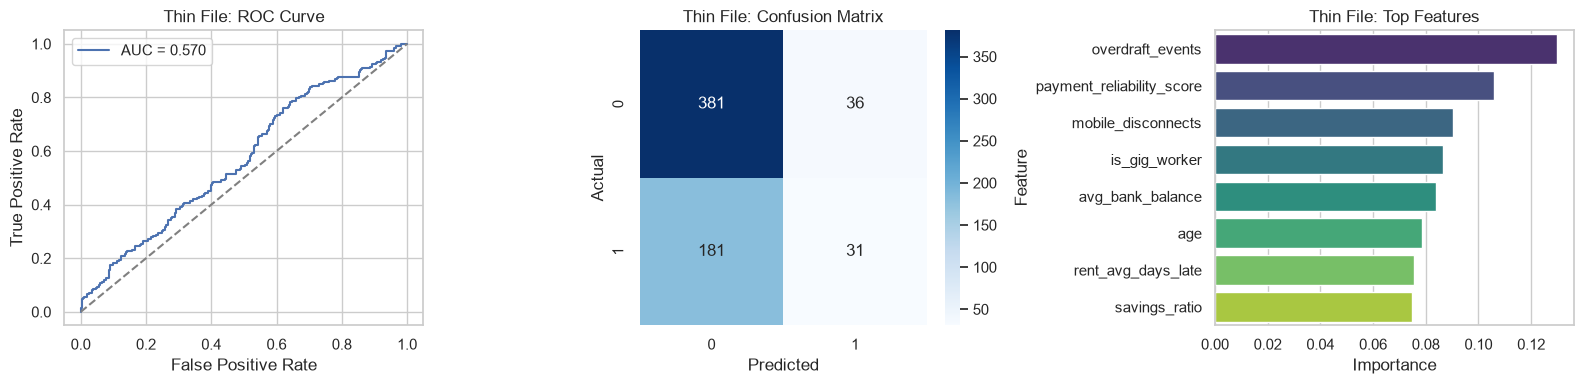

In [3]:
thin_files = df[df['borrower_type'] == 'Thin File'].copy()
traditional = df[df['borrower_type'] == 'Traditional'].copy()

thin_features = [
    'age', 'utility_on_time_pct', 'rent_avg_days_late', 'mobile_disconnects',
    'avg_bank_balance', 'overdraft_events', 'job_tenure_months', 'savings_ratio',
    'debt_to_income_ratio', 'income_stability_score', 'is_gig_worker', 'payment_reliability_score'
]

trad_features = thin_features + [
    'credit_score', 'traditional_payment_history_pct', 'credit_inquiries'
]

X_thin = thin_files[thin_features]
y_thin = thin_files['is_default']
thin_model = train_evaluate_model(X_thin, y_thin, "Thin File")

## Traditional Model

/Users/vishalpatil/Data Science/Thin File Borrower Risk Assessment Platform/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:31:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Traditional Model ---
ROC AUC: 0.5950
              precision    recall  f1-score   support

           0       0.77      0.96      0.85      1037
           1       0.40      0.09      0.15       335

    accuracy                           0.74      1372
   macro avg       0.58      0.52      0.50      1372
weighted avg       0.68      0.74      0.68      1372



/var/folders/1w/wn31x_g14vbd2br3ln9s2nrc0000gn/T/ipykernel_37649/967286594.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', ax=axes[2], palette='viridis')


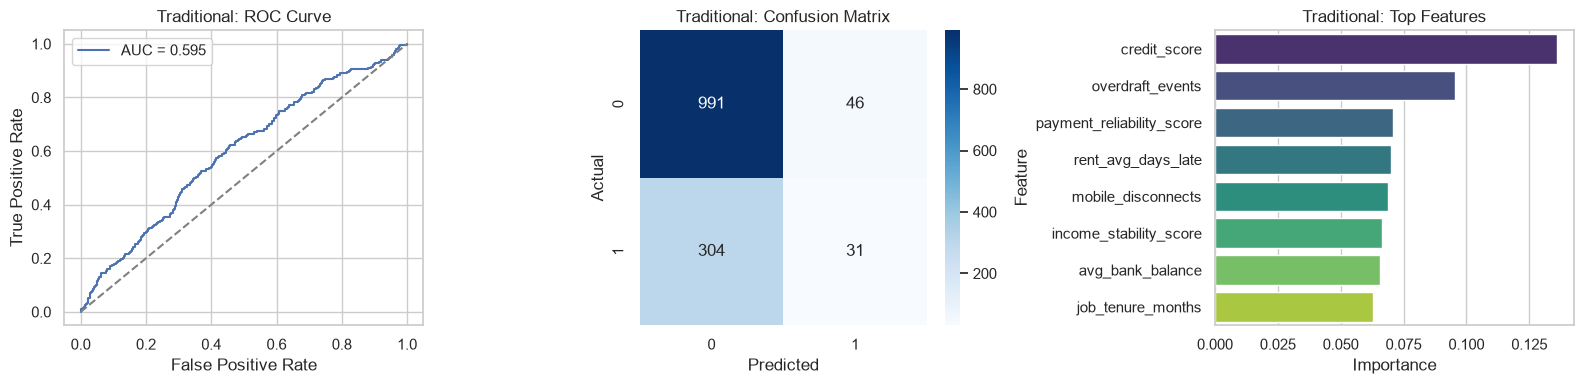

In [4]:
X_trad = traditional[trad_features]
y_trad = traditional['is_default']
trad_model = train_evaluate_model(X_trad, y_trad, "Traditional")

## Score the Full Population & Assign Risk Categories

In [5]:
df['risk_probability'] = np.nan

df.loc[df['borrower_type'] == 'Thin File', 'risk_probability'] = thin_model.predict_proba(
    df.loc[df['borrower_type'] == 'Thin File', thin_features])[:, 1]

df.loc[df['borrower_type'] == 'Traditional', 'risk_probability'] = trad_model.predict_proba(
    df.loc[df['borrower_type'] == 'Traditional', trad_features])[:, 1]

def assign_risk_category(prob):
    if prob < 0.2:
        return 'Low Risk'
    elif prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['risk_category'] = df['risk_probability'].apply(assign_risk_category)
df[['borrower_id', 'borrower_type', 'risk_probability', 'risk_category']].head()

,borrower_id,borrower_type,risk_probability,risk_category
0,B_000000,Thin File,0.366379,Medium Risk
1,B_000001,Traditional,0.171437,Low Risk
2,B_000002,Traditional,0.157068,Low Risk
3,B_000003,Traditional,0.515318,Medium Risk
4,B_000004,Traditional,0.197220,Low Risk


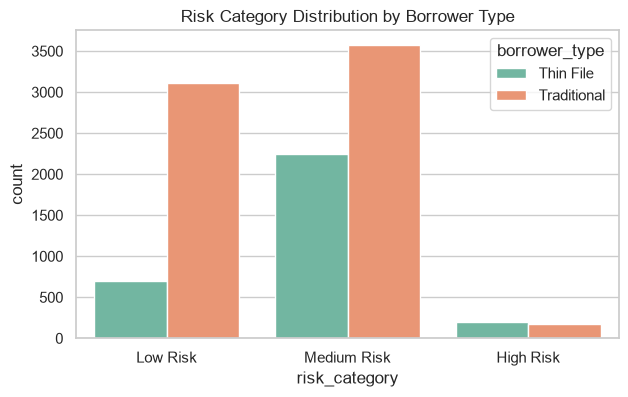

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='risk_category', hue='borrower_type',
               order=['Low Risk', 'Medium Risk', 'High Risk'], palette='Set2', ax=ax)
ax.set_title('Risk Category Distribution by Borrower Type')
plt.show()

## Explainability with SHAP

Credit decisions need to be explainable, not just accurate. [SHAP](https://shap.readthedocs.io/) attributes each prediction to the features that drove it, which is the standard approach for adverse-action/approval reasoning in lending — entirely local computation, no external API calls.

In [7]:
import shap

thin_explainer = shap.TreeExplainer(thin_model)
thin_shap_values = thin_explainer(X_thin)

trad_explainer = shap.TreeExplainer(trad_model)
trad_shap_values = trad_explainer(X_trad)

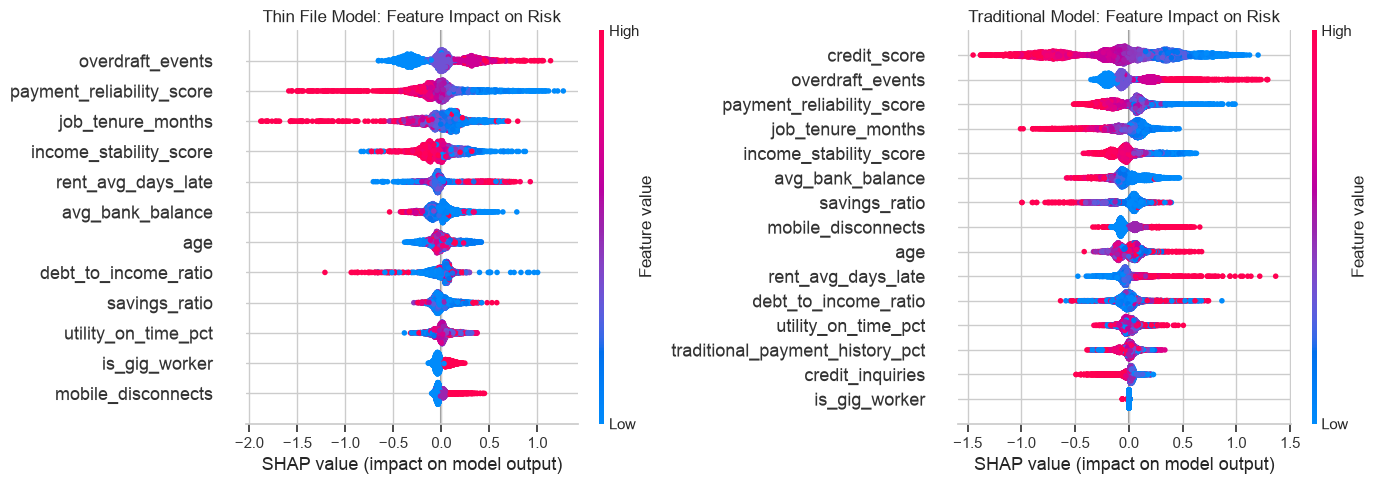

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.summary_plot(thin_shap_values, X_thin, show=False, plot_size=None)
axes[0].set_title('Thin File Model: Feature Impact on Risk')

plt.sca(axes[1])
shap.summary_plot(trad_shap_values, X_trad, show=False, plot_size=None)
axes[1].set_title('Traditional Model: Feature Impact on Risk')

plt.tight_layout()
plt.show()

### Per-Borrower Explanations

Turns SHAP values for a single borrower into a plain-English explanation using a template, not a generative model — costs nothing to run and stays consistent/auditable.

In [9]:
FEATURE_LABELS = {
    'utility_on_time_pct': 'on-time utility payments',
    'rent_avg_days_late': 'rent payment lateness',
    'mobile_disconnects': 'mobile service disconnects',
    'avg_bank_balance': 'average bank balance',
    'overdraft_events': 'bank overdraft frequency',
    'job_tenure_months': 'job tenure',
    'savings_ratio': 'savings-to-income ratio',
    'debt_to_income_ratio': 'debt-to-income ratio',
    'income_stability_score': 'income stability',
    'is_gig_worker': 'gig-worker status',
    'payment_reliability_score': 'overall payment reliability',
    'age': 'age',
    'credit_score': 'credit score',
    'traditional_payment_history_pct': 'traditional payment history',
    'credit_inquiries': 'recent credit inquiries',
}

def explain_borrower(row_idx, X, shap_values, top_n=3):
    """Builds a plain-English explanation from SHAP values for one borrower (positional row index in X)."""
    contributions = pd.Series(shap_values.values[row_idx], index=X.columns)
    contributions = contributions.reindex(contributions.abs().sort_values(ascending=False).index)

    increasing = contributions[contributions > 0].head(top_n)
    decreasing = contributions[contributions < 0].head(top_n)

    lines = []
    for feature in increasing.index:
        label = FEATURE_LABELS.get(feature, feature)
        lines.append(f"- {label} increased the predicted risk")
    for feature in decreasing.index:
        label = FEATURE_LABELS.get(feature, feature)
        lines.append(f"- {label} decreased the predicted risk")

    return "\n".join(lines) if lines else "No strong risk drivers identified."

# Example: explain the first thin-file borrower in the training set
example_borrower_id = thin_files.iloc[0]['borrower_id']
print(f"Explanation for borrower {example_borrower_id}:\n")
print(explain_borrower(0, X_thin, thin_shap_values))

Explanation for borrower B_000000:

- job tenure increased the predicted risk
- income stability increased the predicted risk
- on-time utility payments increased the predicted risk
- bank overdraft frequency decreased the predicted risk
- age decreased the predicted risk
- savings-to-income ratio decreased the predicted risk


## Save Risk Assessments

In [10]:
output_path = '../data/borrower_assessments.csv'
df.to_csv(output_path, index=False)
print(f"Risk assessments saved to {output_path}")

Risk assessments saved to ../data/borrower_assessments.csv
